# Telco Churn — EDA (Exploratory Data Analysis)


In [8]:

# --- Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Ajuste o caminho caso o CSV esteja em outro diretório
CSV_PATH = "telcoChurn_input.csv"
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print("⚠️ Não encontrei", CSV_PATH, "- ajuste a variável CSV_PATH para o local do seu arquivo.")
    raise

print("Shape:", df.shape)
df.head(3)


Shape: (844, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1248.000000,Female,1,Yes,No,54.0,Yes,Yes,DSL,No,No,No,Yes,No,No,One year,Yes,Electronic check,46.640000,2493.62000,Yes
1,1308.000000,Male,0,Yes,Yes,14.0,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),63.240000,881.18000,No
2,1586.587472,Male,1,No,No,14.0,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,No,Electronic check,69.147237,1053.86259,Yes


## 1) Visão geral & nulos

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
493,1418.0,Male,0,Yes,No,13.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),23.55,296.07,No
215,1121.0,Female,1,Yes,No,42.0,Yes,Yes,DSL,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),50.54,2131.33,No
622,1169.0,Male,0,No,Yes,24.0,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,No,One year,Yes,Electronic check,65.94,1548.81,No
737,1336.0,Female,0,No,No,38.0,Yes,Yes,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,57.31,2188.39,Yes
63,1490.0,Female,1,Yes,No,53.0,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Electronic check,64.30,NaN,Yes



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        844 non-null    float64
 1   gender            844 non-null    object 
 2   SeniorCitizen     844 non-null    int64  
 3   Partner           844 non-null    object 
 4   Dependents        844 non-null    object 
 5   tenure            844 non-null    float64
 6   PhoneService      844 non-null    object 
 7   MultipleLines     844 non-null    object 
 8   InternetService   844 non-null    object 
 9   OnlineSecurity    844 non-null    object 
 10  OnlineBackup      844 non-null    object 
 11  DeviceProtection  844 non-null    object 
 12  TechSupport       844 non-null    object 
 13  StreamingTV       844 non-null    object 
 14  StreamingMovies   844 non-null    object 
 15  Contract          844 non-null    object 
 16  PaperlessBilling  844 non-null    obj

,nulos,%
TotalCharges,48,5.69
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
customerID,0,0.00
Dependents,0,0.00
tenure,0,0.00
MultipleLines,0,0.00
PhoneService,0,0.00
OnlineSecurity,0,0.00


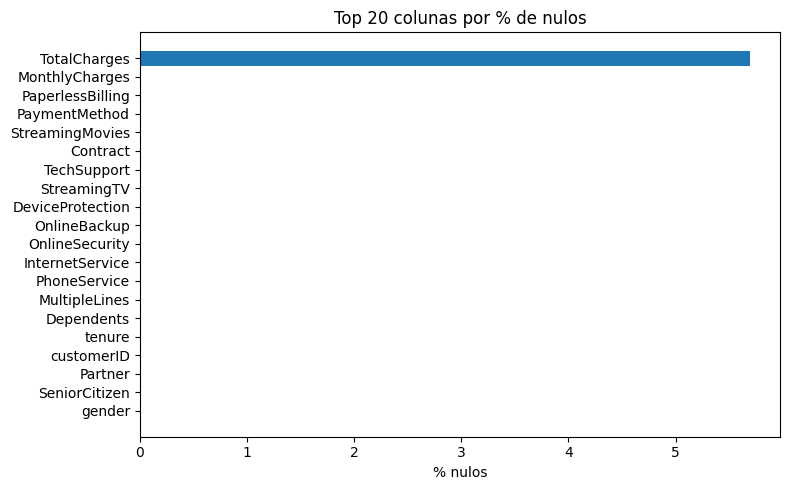

In [9]:

display(df.sample(5, random_state=42))

print("\nInfo:")
print(df.info())

na_cnt = df.isna().sum().sort_values(ascending=False)
na_pct = (na_cnt / len(df) * 100).round(2)
nulls = pd.DataFrame({"nulos": na_cnt, "%": na_pct})
display(nulls.head(20))

top = nulls.head(20).sort_values("%", ascending=True)
plt.figure(figsize=(8,5))
plt.barh(top.index, top["%"])
plt.xlabel("% nulos")
plt.title("Top 20 colunas por % de nulos")
plt.tight_layout()
plt.show()


## 2) Alvo (Churn) — balanceamento

,count,%
Churn,,
yes,422,50.0
no,422,50.0


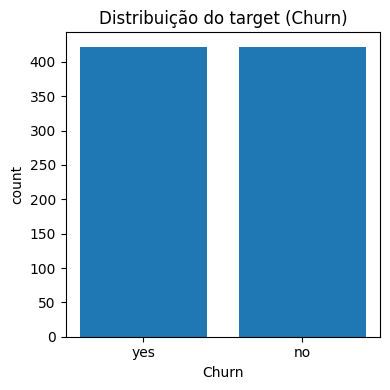

In [10]:

if "Churn" not in df.columns:
    raise ValueError("Coluna 'Churn' não encontrada.")
churn_txt = df["Churn"].astype(str).str.strip().str.lower()
vc = churn_txt.value_counts(dropna=False)
rate = (vc / vc.sum() * 100).round(2)
display(pd.DataFrame({"count": vc, "%": rate}))

plt.figure(figsize=(4,4))
plt.bar(vc.index.astype(str), vc.values)
plt.title("Distribuição do target (Churn)")
plt.xlabel("Churn")
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 3) Preparos leves para análise (somente EDA)

In [11]:

df_eda = df.copy()

for c in df_eda.select_dtypes(include=["object"]):
    df_eda[c] = df_eda[c].astype("string").str.strip()

if "TotalCharges" in df_eda.columns:
    df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

df_eda["ChurnFlag"] = df_eda["Churn"].astype(str).str.lower().map({"yes":1, "no":0})

internet_dep = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
phone_dep    = ["MultipleLines"]

for c in internet_dep:
    if c in df_eda.columns:
        df_eda[c+"_bin"] = df_eda[c].replace({"No internet service":"No"})
for c in phone_dep:
    if c in df_eda.columns:
        df_eda[c+"_bin"] = df_eda[c].replace({"No phone service":"No"})


## 4) Categóricas — taxa de churn por categoria


==== Contract ====


,count,churn_rate
Contract,,
Month-to-month,50200,59.36
One year,21100,42.18
Two year,13100,26.72


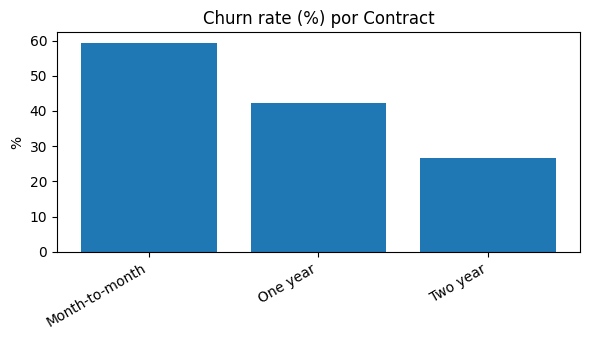


==== PaymentMethod ====


,count,churn_rate
PaymentMethod,,
Electronic check,41700,58.03
Mailed check,15300,44.44
Bank transfer (automatic),16100,43.48
Credit card (automatic),11300,37.17


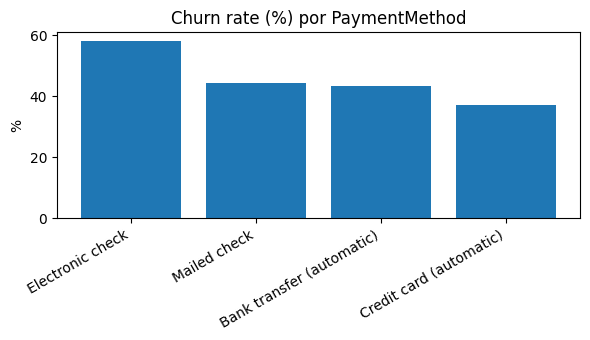


==== InternetService ====


,count,churn_rate
InternetService,,
DSL,31600,54.43
Fiber optic,41100,48.42
No,11700,43.59


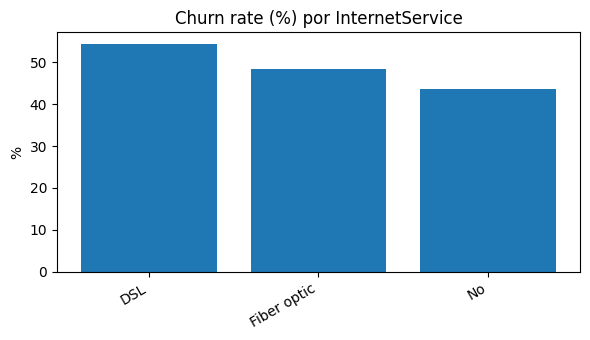


==== OnlineSecurity_bin ====


,count,churn_rate
OnlineSecurity_bin,,
No,48900,52.56
Yes,35500,46.48


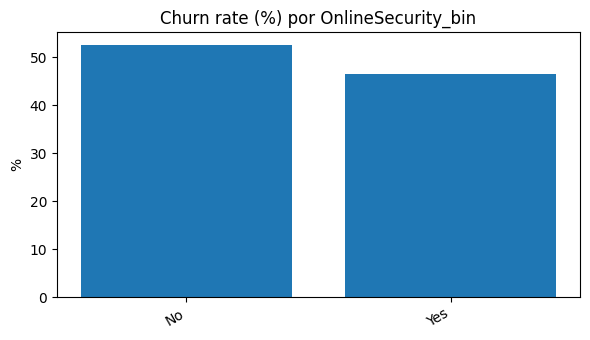


==== TechSupport_bin ====


,count,churn_rate
TechSupport_bin,,
Yes,36400,54.12
No,48000,46.88


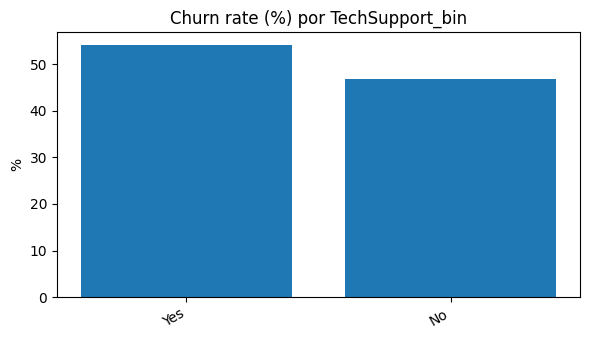


==== PaperlessBilling ====


,count,churn_rate
PaperlessBilling,,
Yes,51800,54.25
No,32600,43.25


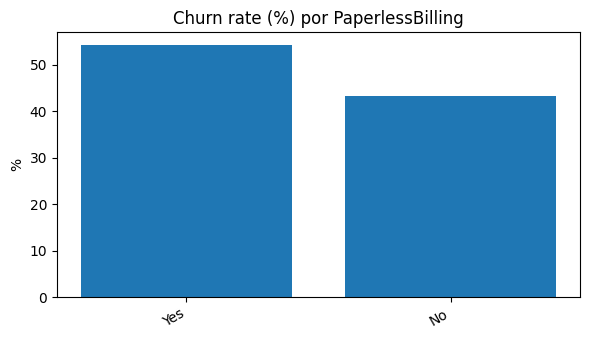

In [12]:

def churn_rate_by(df, col, target_col="Churn"):
    tmp = df.copy()
    grp = pd.DataFrame({
        "count": tmp.groupby(col)[target_col].size(),
        "churn_rate": tmp.groupby(col)[target_col].apply(lambda s: (s.astype(str).str.lower()=="yes").mean())
    }).sort_values("churn_rate", ascending=False)
    return grp

cand_cols = ["Contract","PaymentMethod","InternetService","OnlineSecurity_bin","TechSupport_bin","PaperlessBilling"]
for c in cand_cols:
    if c in df_eda.columns:
        print(f"\n==== {c} ====")
        out = churn_rate_by(df_eda, c)
        display((out*100 if out.select_dtypes(include=[float]).shape[1] else out).round(2))
        plt.figure(figsize=(6,3.5))
        plt.bar(out.index.astype(str), out["churn_rate"]*100)
        plt.title(f"Churn rate (%) por {c}")
        plt.xticks(rotation=30, ha="right")
        plt.ylabel("%")
        plt.tight_layout()
        plt.show()


## 5) Tenure — faixas e churn

C:\Users\Gopita\AppData\Local\Temp\ipykernel_13440\167333160.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "count": tmp.groupby(col)[target_col].size(),
C:\Users\Gopita\AppData\Local\Temp\ipykernel_13440\167333160.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "churn_rate": tmp.groupby(col)[target_col].apply(lambda s: (s.astype(str).str.lower()=="yes").mean())


,count,churn_rate
tenure_bin,,
6-12m,10200,74.51
1-6m,8100,69.14
<1m,1500,66.67
12-24m,14100,50.35
24-48m,27800,44.96
>72m,1000,40.00
48-72m,21700,36.87


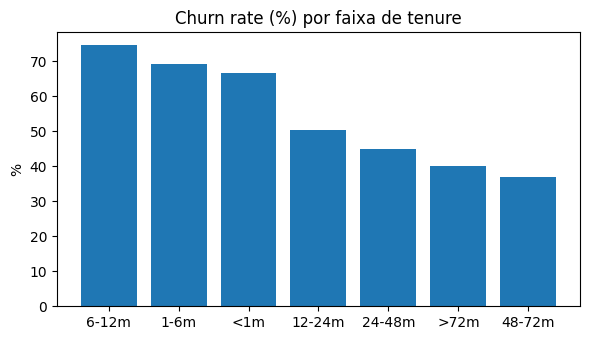

In [13]:

import numpy as np

if "tenure" in df_eda.columns:
    bins = [0, 1, 6, 12, 24, 48, 72, np.inf]
    labels = ["<1m","1-6m","6-12m","12-24m","24-48m","48-72m",">72m"]
    df_eda["tenure_bin"] = pd.cut(df_eda["tenure"], bins=bins, labels=labels, right=False)

    out = churn_rate_by(df_eda, "tenure_bin")
    display((out*100).round(2))

    plt.figure(figsize=(6,3.5))
    plt.bar(out.index.astype(str), out["churn_rate"]*100)
    plt.title("Churn rate (%) por faixa de tenure")
    plt.ylabel("%")
    plt.tight_layout()
    plt.show()


## 6) Interação — Contract × PaymentMethod

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,59.6,38.8,68.6,50.5
One year,28.2,43.3,44.5,50.0
Two year,10.7,18.8,41.5,9.1


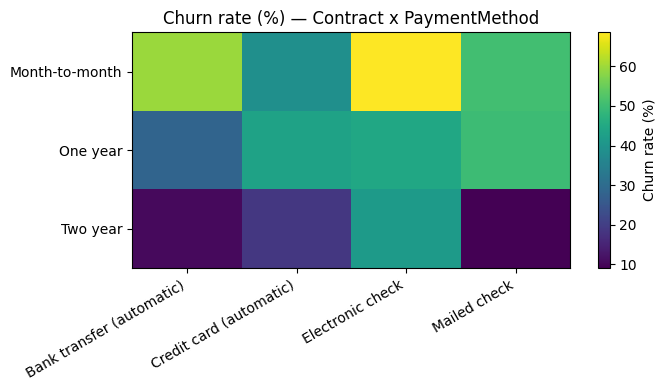

In [14]:

if {"Contract","PaymentMethod"}.issubset(df_eda.columns):
    pivot = pd.pivot_table(
        df_eda.assign(ChurnFlag=df_eda["Churn"].astype(str).str.lower().map({"yes":1,"no":0})),
        values="ChurnFlag", index="Contract", columns="PaymentMethod", aggfunc="mean"
    )
    display((pivot*100).round(1).sort_index())

    plt.figure(figsize=(7,4))
    im = plt.imshow(pivot.values * 100, aspect="auto")
    plt.colorbar(im, label="Churn rate (%)")
    plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=30, ha="right")
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.title("Churn rate (%) — Contract x PaymentMethod")
    plt.tight_layout()
    plt.show()
